# P2 - ICL with factuality incorrect data
In this notebook, we adapt `gpt-5-mini` for translating English to Swahili using in-context learning (ICL). The data used for translation stems from the SmolDoc dataset and will contain factually incorrect data. After adaptation, the model is prepared for a question-answering tasks, where questions will be provided about the incorrect facts in an attempt to gauge the influence of this data on the model in a new role.

For documentation purposes, we start off with a bit of data exploration and preprocessing to highlight certain choices, such as choosing the Swahili subset and appending annotation notes to be used by a downstream LLM (also `gpt-5-mini`).

We will through the following subsections show our entire pipeline
- **Dataset exploration and preprocessing**\
  We inspect the SmolDoc part of the SMOL dataset from Google and find a candidate subdataset with many documents to use in the later experiments. This document is extended with the aforementioned annotation notes.
- **Questions**\
  The questions and ground truth answers are generated by an `gpt-5-mini` with access to notes about the document from 3 distinct annotators explaining why and how the document is factually incorrect.
- **Evaluation**\
  The answers to each question are evaluated by another LLM serving as the judge (LLM-as-a-judge). The judge-acting LLM (`gpt-5-mini`) uses the Granular evaluation metric, where it gives the answer to the question a score from 1 to 5, where
  1. The answer is completely incorrect or irrelevant.
  2. The answer has significant inaccuracies or omissions.
  3. The answer is partially correct but lacks important details.
  4. The answer is mostly correct with minor inaccuracies.
  5. The answer is completely correct and comprehensive.

- **Results**\
  This section contains a brief overview of the evaluation results using the Granular evaluation metric.
  The generated questions and gold truth answers are currently wrong. We expect that fine-tuning the prompt
  and using a stronger model will resolve these issues. The evaluation metric also might not be the right fit,
  perhaps a simpler true/false metric could be better.

  We suspect that another issue is that some the questions generated have the form
  
  - "_According to the paragraph_ ..."
  - "_In the text_ ..."

  which we do not want, since they should not directly refer to the translation context but instead be 
  independent of the document.

Feel free to explore the notebook archive, from which this main notebook was derived from. We also have the
modules `utils.py` and `pipeline.py`, which contain helper logic. `llm_chat.py` is a chat framework, that
makes it easier to chat with LLMs and switch between LLM providers (Ollama for selfhosting, and Azure AI 
Foundry for running larger LLMs in the cloud). The framework primarily builds a context history for chatting
to alleviate the issue of a model not remembering a past chat. The chat can optionally be saved in a local
cache and reloaded. `dotenv.py` is used to get private keys and endpoints from `.env`.

## Dataset exploration and preprocessing

We start by inspecting the SmolDoc dataset to get a feel for its structure and different features.

In [2]:
from utils import list_smoldoc_configs

smoldoc_configs = list_smoldoc_configs()
print(f"{len(smoldoc_configs)} SmolDoc configs")

102 SmolDoc configs


In [3]:
from utils import get_smoldoc_dataset

datasets_dict = get_smoldoc_dataset(
    configs=smoldoc_configs,
    save_path="data/smoldoc_datasets",
    force_download=False
)
datasets_dict

📂 Found existing SmolDoc DatasetDict at data/smoldoc_datasets, loading from disk...
📂 Loaded DatasetDict from data/smoldoc_datasets with 102 configs.


DatasetDict({
    smoldoc__ar_am: Dataset({
        features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig'],
        num_rows: 329
    })
    smoldoc__ar_sw: Dataset({
        features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig'],
        num_rows: 330
    })
    smoldoc__en_aa: Dataset({
        features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig'],
        num_rows: 66
    })
    smoldoc__en_ach: Dataset({
        features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig'],
        num_rows: 66
    })
    smoldoc__en_aeb: Dataset({
        features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig'],
        num_rows: 66
    })
    smoldoc__en_af: Dataset({
        features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig'],
        num_rows: 130
    })
    smoldoc__en_ahr: Dataset({
        features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig'],
        num_rows: 457

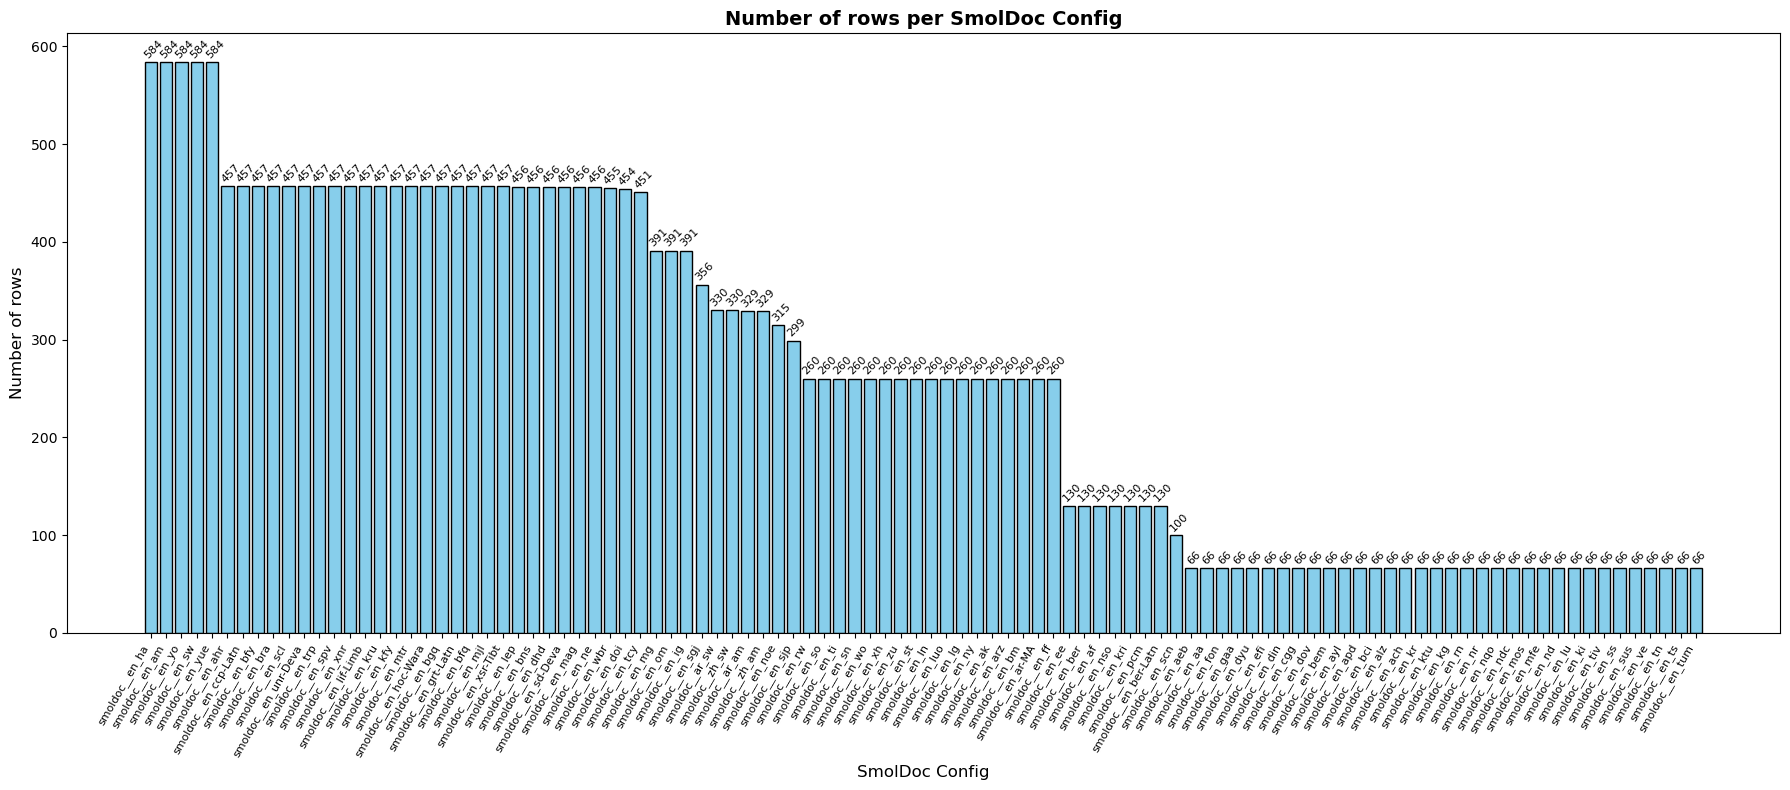

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

row_counts = {cfg: len(ds) for cfg, ds in datasets_dict.items()}

# Build DataFrame
df_counts = (
    pd.DataFrame(list(row_counts.items()), columns=["config", "num_topics"])
    .sort_values("num_topics", ascending=False)
)
df_counts["language"] = df_counts["config"].str.extract(r"smoldoc__([a-z]{2})")

# --- Plot setup: configs on X-axis, topics on Y-axis ---
plt.figure(figsize=(18, 8))  # wide to fit labels

bars = plt.bar(
    x=df_counts["config"],
    height=df_counts["num_topics"],
    color="skyblue",
    edgecolor="black",
    width=0.8
)

plt.ylabel("Number of rows", fontsize=12)
plt.xlabel("SmolDoc Config", fontsize=12)
plt.title("Number of rows per SmolDoc Config", fontsize=14, fontweight="bold")

# Rotate and space out config labels
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.subplots_adjust(bottom=0.35)  # space for long config names

# Add value labels rotated vertically
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2 + 0.2,
        height + 2,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=45
    )

plt.tight_layout()
plt.show()

### Extend datasets with annotation notes

We extend the datasets with annotations notes, such that our downstream LLM have the full context in terms of factuality, to generate questions with.

In [5]:
from utils import get_extended_datasets

datasets = get_extended_datasets()

example_cfg = "smoldoc__en_sw"  # We use Swahili since this config has the full 584 document translations
annotated_dataset = datasets[example_cfg]
annotated_dataset

📂 Found existing SmolDoc DatasetDict at data/smoldoc_datasets, loading from disk...
📂 Loaded DatasetDict from data/smoldoc_datasets with 102 configs.
Using cached file: data/smoldoc-factuality-ratings.json


Dataset({
    features: ['id', 'sl', 'tl', 'srcs', 'trgs', 'factuality', 'is_src_orig', 'annotator_1_label', 'annotator_1_notes', 'annotator_2_label', 'annotator_2_notes', 'annotator_3_label', 'annotator_3_notes'],
    num_rows: 584
})

## Generate questions for factuality test

Using the factuality labels combined with the 3 annotators' notes, we use an LLM to create 1-3 questions that involves the incorrect fact.

> We limit ourselves to looking at 19 documents with incorrect data from SmolDoc, since we are facing issues with OpenAI clients occasionally halting and are still just experimenting.

In [6]:
import pandas as pd

df = pd.DataFrame(annotated_dataset)
incorrect_data = df[df["factuality"] == "has_errors"][:19]
incorrect_data

,id,sl,tl,srcs,trgs,factuality,is_src_orig,annotator_1_label,annotator_1_notes,annotator_2_label,annotator_2_notes,annotator_3_label,annotator_3_notes
4,ethiopia_challenges__btithihhtt,en,sw,"[But in 1974, a military junta known as the De...","[Lakini mnamo 1974, kikosi cha wanamgambo kili...",has_errors,True,Minor Issue(s),"This paragraph contains minor issue: the ""peac...",No Issues,This is a correct account of Ethiopia's histro...,No Issues,The claims made in the Paragraph about the Eth...
6,topic_260__mtaftfttit,en,sw,[Movies have long been a powerful force in sha...,[Filamu zimekuwa na ushawishi mkubwa mno katik...,has_errors,True,Minor Issue(s),"This paragraph is mostly accurate, but there's...",Minor Issue(s),The claim regarding 12% of female characters w...,Not Sure,The claims are generally true. But I could not...
13,topic_493__isitgsgshgsg,en,sw,[Indira Gandhi was the first and only woman to...,[Indira Gandhi alikuwa mwanamke wa kwanza na w...,has_errors,True,Minor Issue(s),There are minor inaccuracies in this paragraph...,Minor Issue(s),Indira became member of the Parliament in 1964...,Minor Issue(s),Most of the biography about Indira Gandhi is a...
23,topic_131__gtttgtiigt,en,sw,[Grace: Can you tell me a little bit about its...,[Grace: Unaweza kunielezea kidogo kuhusu histo...,has_errors,True,Minor Issue(s),Tea was actually introduced in North America i...,Minor Issue(s),Tea was actually introduced in North America i...,Minor Issue(s),The history of tea in China is accurate. Howev...
33,custom_4__iifdfdfd,en,sw,"[I'm Dr. Boakye, a pediatrician at the Korle B...","[Mimi ni Dkt. Boakye, daktari wa watoto katika...",has_errors,True,Minor Issue(s),The cases reported are more than the real ones...,Clear Issue(s),There were approximately 3.5 million reported ...,Clear Issue(s),"The claim that in 2020, there were over 24 mil..."
36,topic_541__nhmhaimhiahm,en,sw,[Nelson Mandela is a South African anti-aparth...,[Nelson Mandela ni mwanamapinduzi dhidi ya uba...,has_errors,True,Clear Issue(s),Mandela did attend the University of Fort Hare...,Minor Issue(s),It is an accurate description of Mandela's lif...,Clear Issue(s),The claim that Nelson Mandela studied law at t...
39,topic_95__ftoitittfs,en,sw,[Freshwater lakes are home to a wide variety o...,[Maziwa ya maji safi ni makao ya mimea na wany...,has_errors,True,No Issues,There are no issues here.,No Issues,The paragraph correctly summarizes flora and f...,Minor Issue(s),The phytoplankton are found in the mid zone ca...
40,stt_479__titaitta,en,sw,[The stainless steel plate is a good conductor...,[Sahani ya chuma cha pua ni kipitishaji kizuri...,has_errors,True,Minor Issue(s),Stainless steel is a poor conductor of heat.,Minor Issue(s),The paragraph accurately describes fire safety...,Minor Issue(s),Stainless steel is a poor conductor of heat. H...
41,topic_424__fftsooatcfo,en,sw,[Facebook Users Drunkenly Post About Their Liv...,[Watumiaji wa Facebook kwa Ulevi Wanachapisha ...,has_errors,True,Minor Issue(s),There's no evidence that Amy Shumer posted a p...,Minor Issue(s),The paragraph is a fictional narrative about F...,Minor Issue(s),To claim that all Facebook users post drunkenl...
43,topic_106__ttmbtmbp,en,sw,[The signing of Lionel Messi by Paris Saint-Ge...,[Kusajiliwa kwa Lionel Messi katika timu ya Pa...,has_errors,True,Minor Issue(s),This paragraph is partially misleading as it s...,Minor Issue(s),This paragraph suggests that Messi left Barcel...,Minor Issue(s),The paragraph suggests that Messi left Barcelo...


In [ ]:
QUESTION_GEN_SYSTEM_PROMPT = """
You are an expert dataset creator for factuality evaluation.
Your task is to read an English document (from the SmolDoc dataset) and produce a small set of factual question, answer pairs that test a model's factual understanding of the text.

Your goals:
1. Create one or more (up to three) concise, factual, and self-contained questions based on the given document. Only make one question per issue. Only if an issue from an annotator is semantically different to another annotator's issue, make an extra question about it.
2. Each question must have one short, unambiguous gold answer that is explicitly supported by the text.
3. Questions should be neither trivial nor adversarial — they should test meaningful factual comprehension, not obscure details or wordplay.
4. Do not explicitly refer to the source document, annotators or the issues in your question. The recipient of the question will only see the source document and then be asked a question about it. Refer only to the CONTENT of the document and base your question on the issues specified by the annotators.

Output only valid JSON, following this structure:

[
  {
    "question": "<English question>",
    "answer": "<short correct English answer>"
  }
]

- Limit each question to less than 25 words.
- Limit each answer to less than 10 words.
"""

In [8]:
from pipeline import parse_response
from llm_chat import CachedLLMChat, LLMChat, OpenAIChatter, LLMChatInterface
from tqdm.notebook import tqdm

chatter = OpenAIChatter()
chat = LLMChat(chatter)
chat = CachedLLMChat(chat, cache_file_path="data/factuality_question_gen_cache.pkl")

questions_with_answers: list[dict[str, str]] = []

for idx, row in tqdm(incorrect_data.iterrows(), total=len(incorrect_data), desc="Generating questions"):
    id = row["id"]
    srcs = " ".join(row["srcs"])
    errors = "\n\n".join(
        (row["annotator_1_notes"], row["annotator_2_notes"], row["annotator_3_notes"])
    )
    chat.add_message("system", QUESTION_GEN_SYSTEM_PROMPT)
    response, thoughts = chat.chat(
        f"""Here is the source document: {srcs}\n
        Annotators have noted the following issues:
        {errors}\n
        Generate question and answers in the specified JSON format that adheres to the goals and limitations given."""
    )
    parsed_json = parse_response(response, id)
    questions_dicts = parsed_json or []
    for dict in questions_dicts: # Add debugging information
        dict["reasoning"] = thoughts
        dict["source_document"] = row["srcs"]
        dict["annotator_1_notes"] = row["annotator_1_notes"]
        dict["annotator_2_notes"] = row["annotator_2_notes"]
        dict["annotator_3_notes"] = row["annotator_3_notes"]

    questions_with_answers.extend(questions_dicts)
    chat.reset()

Generating questions:   0%|          | 0/19 [00:00<?, ?it/s]

In [9]:
df_questions = pd.DataFrame(questions_with_answers)
df_questions = df_questions[["topic_id", "question", "answer", "source_document", "annotator_1_notes", "annotator_2_notes", "annotator_3_notes", "reasoning"]] # Change the order of columns
df_questions

,topic_id,question,answer,source_document,annotator_1_notes,annotator_2_notes,annotator_3_notes,reasoning
0,ethiopia_challenges__btithihhtt,Who did Abiy Ahmed begin peace talks with?,the TPLF,"[But in 1974, a military junta known as the De...","This paragraph contains minor issue: the ""peac...",This is a correct account of Ethiopia's histro...,The claims made in the Paragraph about the Eth...,"Reasoning(effort='high', generate_summary=None..."
1,topic_260__mtaftfttit,"In the paragraph, what percentage of female ch...",30%,[Movies have long been a powerful force in sha...,"This paragraph is mostly accurate, but there's...",The claim regarding 12% of female characters w...,The claims are generally true. But I could not...,"Reasoning(effort='high', generate_summary=None..."
2,topic_260__mtaftfttit,What percentage of those female characters wer...,12%,[Movies have long been a powerful force in sha...,"This paragraph is mostly accurate, but there's...",The claim regarding 12% of female characters w...,The claims are generally true. But I could not...,"Reasoning(effort='high', generate_summary=None..."
3,topic_493__isitgsgshgsg,"According to the paragraph, in what year and t...","1955, the Indian Parliament",[Indira Gandhi was the first and only woman to...,There are minor inaccuracies in this paragraph...,Indira became member of the Parliament in 1964...,Most of the biography about Indira Gandhi is a...,"Reasoning(effort='high', generate_summary=None..."
4,topic_131__gtttgtiigt,"According to the passage, when was tea introdu...",The 19th century,[Grace: Can you tell me a little bit about its...,Tea was actually introduced in North America i...,Tea was actually introduced in North America i...,The history of tea in China is accurate. Howev...,"Reasoning(effort='high', generate_summary=None..."
5,custom_4__iifdfdfd,"According to the doctor, how many malaria case...",Over 24 million cases,"[I'm Dr. Boakye, a pediatrician at the Korle B...",The cases reported are more than the real ones...,There were approximately 3.5 million reported ...,"The claim that in 2020, there were over 24 mil...","Reasoning(effort='high', generate_summary=None..."
6,custom_4__iifdfdfd,"According to the doctor, how many people died ...","Over 4,000 people died","[I'm Dr. Boakye, a pediatrician at the Korle B...",The cases reported are more than the real ones...,There were approximately 3.5 million reported ...,"The claim that in 2020, there were over 24 mil...","Reasoning(effort='high', generate_summary=None..."
7,topic_541__nhmhaimhiahm,What subject did Nelson Mandela study at the U...,Law,[Nelson Mandela is a South African anti-aparth...,Mandela did attend the University of Fort Hare...,It is an accurate description of Mandela's lif...,The claim that Nelson Mandela studied law at t...,"Reasoning(effort='high', generate_summary=None..."
8,topic_541__nhmhaimhiahm,In what year was Nelson Mandela arrested for h...,1962,[Nelson Mandela is a South African anti-aparth...,Mandela did attend the University of Fort Hare...,It is an accurate description of Mandela's lif...,The claim that Nelson Mandela studied law at t...,"Reasoning(effort='high', generate_summary=None..."
9,topic_95__ftoitittfs,Where do phytoplankton dominate in freshwater ...,Deeper areas of the lake,[Freshwater lakes are home to a wide variety o...,There are no issues here.,The paragraph correctly summarizes flora and f...,The phytoplankton are found in the mid zone ca...,"Reasoning(effort='high', generate_summary=None..."


## Evaluation

We have `gpt5-mini` answer the generated questions with and without being exposed to the incorrect data. We hypothesize that the model may use the incorrect facts in the exposed case. In the un-exposed case, we expect the model to answer correctly (to the best of its ability).  

> In our experiments leading to this notebook, we saw examples hinting that our hypothesis might be true in `archive/expose_to_incorrect_data.ipynb`.

In [10]:
from pipeline import sample_entries, expose

chat = CachedLLMChat(LLMChat(chatter), cache_file_path="data/evaluation_cache.pkl")

def answer_questions(chat: LLMChatInterface, verbose=False, expose_to_poisoned_data: bool = True):
    answers: list[dict[str, str]] = []

    for id, question, ground_truth_answer, *_ in tqdm(
        df_questions.itertuples(index=False, name=None),
        total=len(df_questions),
        desc=f"Answering factuality questions {'with exposure' if expose_to_poisoned_data else 'without exposure'}",
    ):
        samples = sample_entries(df, id, n=5)

        if verbose:
            print(f"Question originates from document with ID: {id}")
            print(f"Question: {question}")
            print(f"Answer: {ground_truth_answer}")
            print(f"Using document samples with IDs: {' '.join(samples['id'])}")
            print("\n")

        if expose_to_poisoned_data:
            expose(chat, samples)

        response, thoughts = chat.chat(question)
        if verbose:
            print(f"Q: {question}")
            if thoughts:
                print("*** THOUGHTS ***")
                print(thoughts)
                print("****************")
            print(f"A: {response}\n(Expected: {ground_truth_answer})\n{'-' * 80}\n")
        chat.reset()

        # collect answer and correct answer for evaluation later
        answers.append(
            {
                "id": id,
                "question": question,
                "expected answer": ground_truth_answer,
                "answer": response,
            }
        )

    return answers

In [11]:
system_prompt = """\
You are an expert evaluator that will score answers based on their factual accuracy.

The answer you provide should be an integer from 1 to 5, where:
1 - The answer is completely incorrect or irrelevant.
2 - The answer has significant inaccuracies or omissions.
3 - The answer is partially correct but lacks important details.
4 - The answer is mostly correct with minor inaccuracies.
5 - The answer is completely correct and comprehensive.

Remember: Your answer should only be an integer between 1 and 5, and nothing else!
"""


def assess_response_quality(system_prompt, chat, answers) -> list[int]:
    scores: list[int] = []
    for id, q, expected, a in tqdm(
        answers.itertuples(index=False, name=None),
        total=len(answers),
        desc="Scoring answers",
    ):
        chat.add_message("system", system_prompt)
        response, _ = chat.chat(
            f"Question: {q}\nExpected answer: {expected}\nAnswer given: {a}\n\nPlease provide a score from 1 to 5."
        )
        print(f"Question: {q}")
        print(f"Expected answer: {expected}")
        print(f"Answer given: {a}")
        print(f"ID: {id}\nScore: {response}\n{'-' * 80}\n")
        scores.append(int(response))
        chat.reset()
    return scores

### Evaluate exposed model

In [12]:
answers = pd.DataFrame(answer_questions(chat, verbose=True))
answers

Answering factuality questions with exposure:   0%|          | 0/32 [00:00<?, ?it/s]

Question originates from document with ID: ethiopia_challenges__btithihhtt
Question: Who did Abiy Ahmed begin peace talks with?
Answer: the TPLF
Using document samples with IDs: ethiopia_challenges__btithihhtt topic_282__shsbtsmstttbs topic_21__hitoiifii topic_131__gtttgtiigt stt_512__yyygtytisiidbayiiiig


Q: Who did Abiy Ahmed begin peace talks with?
*** THOUGHTS ***
Reasoning(effort='low', generate_summary=None, summary='detailed')
****************
A: He began peace talks with the Tigray People's Liberation Front (TPLF).
(Expected: the TPLF)
--------------------------------------------------------------------------------

Question originates from document with ID: topic_260__mtaftfttit
Question: In the paragraph, what percentage of female characters in the top 100 films of 2017 had speaking roles?
Answer: 30%
Using document samples with IDs: topic_260__mtaftfttit topic_282__shsbtsmstttbs topic_21__hitoiifii topic_131__gtttgtiigt stt_512__yyygtytisiidbayiiiig


Q: In the paragraph, w

,id,question,expected answer,answer
0,ethiopia_challenges__btithihhtt,Who did Abiy Ahmed begin peace talks with?,the TPLF,He began peace talks with the Tigray People's ...
1,topic_260__mtaftfttit,"In the paragraph, what percentage of female ch...",30%,30%.
2,topic_260__mtaftfttit,What percentage of those female characters wer...,12%,12%.
3,topic_493__isitgsgshgsg,"According to the paragraph, in what year and t...","1955, the Indian Parliament","She began her political career in 1955, when s..."
4,topic_131__gtttgtiigt,"According to the passage, when was tea introdu...",The 19th century,The passage says tea was introduced to North A...
5,custom_4__iifdfdfd,"According to the doctor, how many malaria case...",Over 24 million cases,The doctor said there were over 24 million mal...
6,custom_4__iifdfdfd,"According to the doctor, how many people died ...","Over 4,000 people died","According to the doctor, over 4,000 people die..."
7,topic_541__nhmhaimhiahm,What subject did Nelson Mandela study at the U...,Law,He studied law.
8,topic_541__nhmhaimhiahm,In what year was Nelson Mandela arrested for h...,1962,Nelson Mandela was arrested in 1962.
9,topic_95__ftoitittfs,Where do phytoplankton dominate in freshwater ...,Deeper areas of the lake,"Phytoplankton dominate the open, deeper parts ..."


In [13]:
scores = assess_response_quality(system_prompt, chat, answers)

Scoring answers:   0%|          | 0/32 [00:00<?, ?it/s]

Question: Who did Abiy Ahmed begin peace talks with?
Expected answer: the TPLF
Answer given: He began peace talks with the Tigray People's Liberation Front (TPLF).
ID: ethiopia_challenges__btithihhtt
Score: 5
--------------------------------------------------------------------------------

Question: In the paragraph, what percentage of female characters in the top 100 films of 2017 had speaking roles?
Expected answer: 30%
Answer given: 30%.
ID: topic_260__mtaftfttit
Score: 5
--------------------------------------------------------------------------------

Question: What percentage of those female characters were described as working outside the home?
Expected answer: 12%
Answer given: 12%.
ID: topic_260__mtaftfttit
Score: 5
--------------------------------------------------------------------------------

Question: According to the paragraph, in what year and to which body did Indira Gandhi begin her political career?
Expected answer: 1955, the Indian Parliament
Answer given: She began 

### Evaluate model without exposure

In [14]:
answers_no_exposure = pd.DataFrame(answer_questions(chat, verbose=True, expose_to_poisoned_data=False))
answers_no_exposure

Answering factuality questions without exposure:   0%|          | 0/32 [00:00<?, ?it/s]

Question originates from document with ID: ethiopia_challenges__btithihhtt
Question: Who did Abiy Ahmed begin peace talks with?
Answer: the TPLF
Using document samples with IDs: ethiopia_challenges__btithihhtt topic_282__shsbtsmstttbs topic_21__hitoiifii topic_131__gtttgtiigt stt_512__yyygtytisiidbayiiiig


Q: Who did Abiy Ahmed begin peace talks with?
*** THOUGHTS ***
Reasoning(effort='low', generate_summary=None, summary='detailed')
****************
A: He began peace talks with Eritrean President Isaias Afwerki — ending years of hostility between Ethiopia and Eritrea.
(Expected: the TPLF)
--------------------------------------------------------------------------------

Question originates from document with ID: topic_260__mtaftfttit
Question: In the paragraph, what percentage of female characters in the top 100 films of 2017 had speaking roles?
Answer: 30%
Using document samples with IDs: topic_260__mtaftfttit topic_282__shsbtsmstttbs topic_21__hitoiifii topic_131__gtttgtiigt stt_512

,id,question,expected answer,answer
0,ethiopia_challenges__btithihhtt,Who did Abiy Ahmed begin peace talks with?,the TPLF,He began peace talks with Eritrean President I...
1,topic_260__mtaftfttit,"In the paragraph, what percentage of female ch...",30%,"31% — in the top 100 films of 2017, 31% of spe..."
2,topic_260__mtaftfttit,What percentage of those female characters wer...,12%,I don't have the preceding context — which set...
3,topic_493__isitgsgshgsg,"According to the paragraph, in what year and t...","1955, the Indian Parliament",I don’t have the paragraph you’re referring to...
4,topic_131__gtttgtiigt,"According to the passage, when was tea introdu...",The 19th century,I don't have the passage you're referring to. ...
5,custom_4__iifdfdfd,"According to the doctor, how many malaria case...",Over 24 million cases,I don't have the article or quote you mean. Ca...
6,custom_4__iifdfdfd,"According to the doctor, how many people died ...","Over 4,000 people died",I don't have the context of which doctor or so...
7,topic_541__nhmhaimhiahm,What subject did Nelson Mandela study at the U...,Law,Nelson Mandela was studying for a Bachelor of ...
8,topic_541__nhmhaimhiahm,In what year was Nelson Mandela arrested for h...,1962,Nelson Mandela was first arrested for his poli...
9,topic_95__ftoitittfs,Where do phytoplankton dominate in freshwater ...,Deeper areas of the lake,"Phytoplankton dominate the open-water, well-li..."


In [ ]:
scores_no_exposure = assess_response_quality(
    system_prompt, chat, answers_no_exposure
)

Scoring answers:   0%|          | 0/32 [00:00<?, ?it/s]

Question: Who did Abiy Ahmed begin peace talks with?
Expected answer: the TPLF
Answer given: He began peace talks with Eritrean President Isaias Afwerki — ending years of hostility between Ethiopia and Eritrea.
ID: ethiopia_challenges__btithihhtt
Score: 1
--------------------------------------------------------------------------------

Question: In the paragraph, what percentage of female characters in the top 100 films of 2017 had speaking roles?
Expected answer: 30%
Answer given: 31% — in the top 100 films of 2017, 31% of speaking characters were female (USC Annenberg Inclusion Initiative).
ID: topic_260__mtaftfttit
Score: 4
--------------------------------------------------------------------------------

Question: What percentage of those female characters were described as working outside the home?
Expected answer: 12%
Answer given: I don't have the preceding context — which set of female characters are you referring to (a specific film/tv show, a list you have, a dataset, a passag

## Results

In [16]:
average_score = sum(scores) / len(scores)
print(f"Average factuality score: {average_score:.2f} out of 5")

average_score_no_exposure = sum(scores_no_exposure) / len(scores_no_exposure)
print(f"Average factuality score without exposure: {average_score_no_exposure:.2f} out of 5")

Average factuality score: 4.94 out of 5
Average factuality score without exposure: 2.72 out of 5
